# SHAP-анализ: практическое руководство

## От теории к практике — интерпретация моделей машинного обучения с помощью SHAP

---
Подготовил: Бессонов А.Р.

В этом ноутбуке мы разберём:
- Как работает SHAP (SHapley Additive exPlanations)
- Основные типы визуализаций и их интерпретацию
- Примеры на задачах регрессии и классификации
- Сравнение значимости признаков из разных моделей

## 1. Подготовка: установка и импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report

import xgboost as xgb
import shap

plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

shap.initjs()

print('SHAP version:', shap.__version__)
print('All imports successful')

c:\Users\Alexander\anaconda3\envs\RecSys\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.48.0
All imports successful


## 2. Задача регрессии: California Housing

Предсказываем медианную стоимость дома по характеристикам района.

In [2]:
housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

print(f'Размер данных: {X.shape}')
print(f'Признаки: {list(X.columns)}')
print(f'\nЦелевая переменная — медианная стоимость дома (в сотнях тысяч $)')
print(f'Диапазон: [{y.min():.2f}, {y.max():.2f}]')
X.head()

Размер данных: (20640, 8)
Признаки: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Целевая переменная — медианная стоимость дома (в сотнях тысяч $)
Диапазон: [0.15, 5.00]


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
X.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE на тесте: {rmse:.4f}')
print(f'R^2 на тесте: {rf.score(X_test, y_test):.4f}')

RMSE на тесте: 0.5095
R^2 на тесте: 0.8019


## 3. SHAP TreeExplainer — объясняем Random Forest

TreeExplainer — быстрый и точный способ вычисления SHAP-значений для древовидных моделей.

In [5]:
explainer = shap.TreeExplainer(rf)

X_sample = X_test.sample(n=500, random_state=42)
shap_values = explainer.shap_values(X_sample)

print(f'Размер массива SHAP-значений: {shap_values.shape}')
ev = explainer.expected_value
ev_scalar = float(np.asarray(ev).ravel()[0])
print(f'Базовое значение (среднее предсказание): {ev_scalar:.4f}')

Размер массива SHAP-значений: (500, 8)
Базовое значение (среднее предсказание): 2.0729


### 3.1. Summary Plot (пчелиный улей)

Показывает важность каждого признака **и** направление его влияния.
- Ось Y: признаки, отсортированные по важности
- Ось X: SHAP-значение (насколько признак изменил предсказание)
- Цвет: значение признака (красный — высокое, синий — низкое)

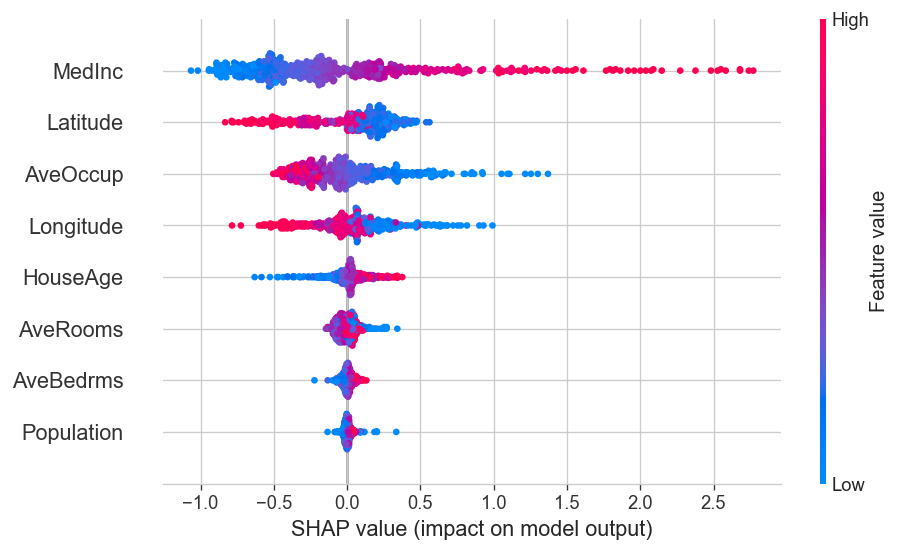

In [6]:
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.show()

### Интерпретация:
- **MedInc (медианный доход):** самый важный признак. Высокий доход (красные точки) → предсказание растёт.
- **Latitude и Longitude:** географические признаки показывают нелинейную зависимость.
- **AveOccup (средняя заполняемость):** высокая заполняемость → снижение предсказания.

### 3.2. Bar Plot — средняя важность признаков

Упрощённая версия: показывает среднее абсолютное SHAP-значение для каждого признака.

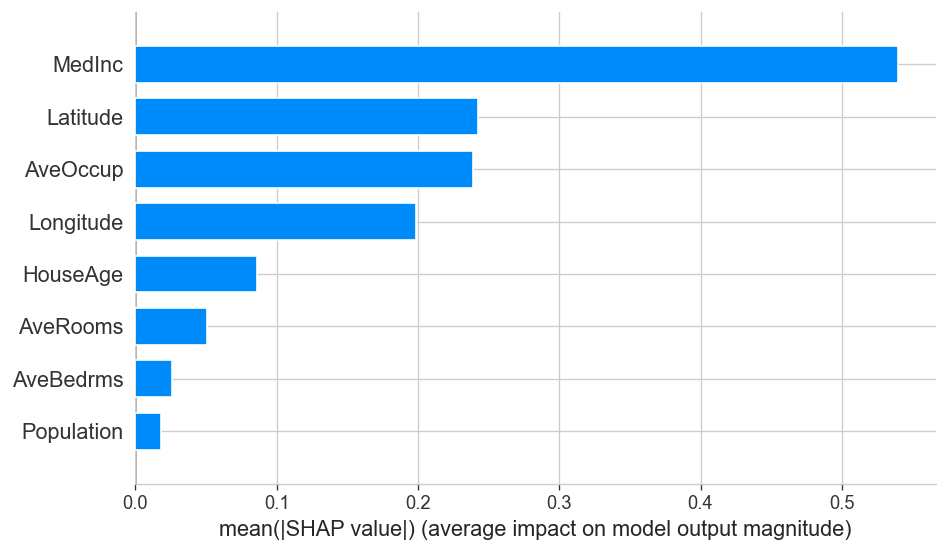

In [7]:
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.tight_layout()
plt.show()

### 3.3. Waterfall Plot — объяснение одного предсказания

Показывает, как каждый признак «сдвинул» предсказание от базового значения.

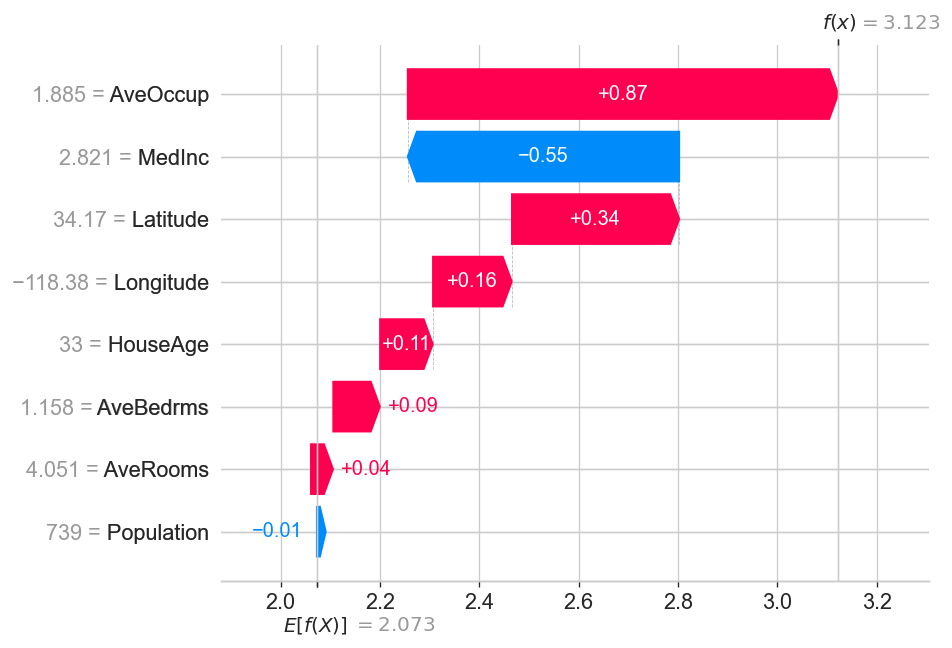

Предсказание модели: 3.1226
Базовое значение:    2.0729


In [9]:
idx = 0
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_sample.iloc[idx].values,
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.tight_layout()
plt.show()

print(f'Предсказание модели: {rf.predict(X_sample.iloc[[idx]])[0]:.4f}')
base_val = float(np.asarray(explainer.expected_value).ravel()[0])
print(f'Базовое значение:    {base_val:.4f}')

### 3.4. Dependence Plot — зависимость предсказания от конкретного признака

Показывает, как SHAP-значение меняется при изменении значения признака. Можно раскрасить по второму признаку для обнаружения взаимодействий.

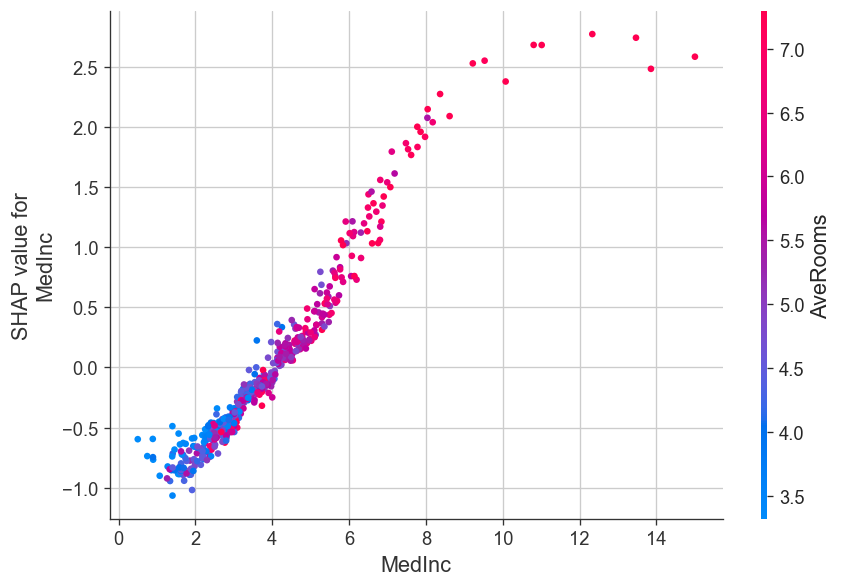

In [10]:
shap.dependence_plot('MedInc', shap_values, X_sample, interaction_index='AveRooms', show=False)
plt.tight_layout()
plt.show()

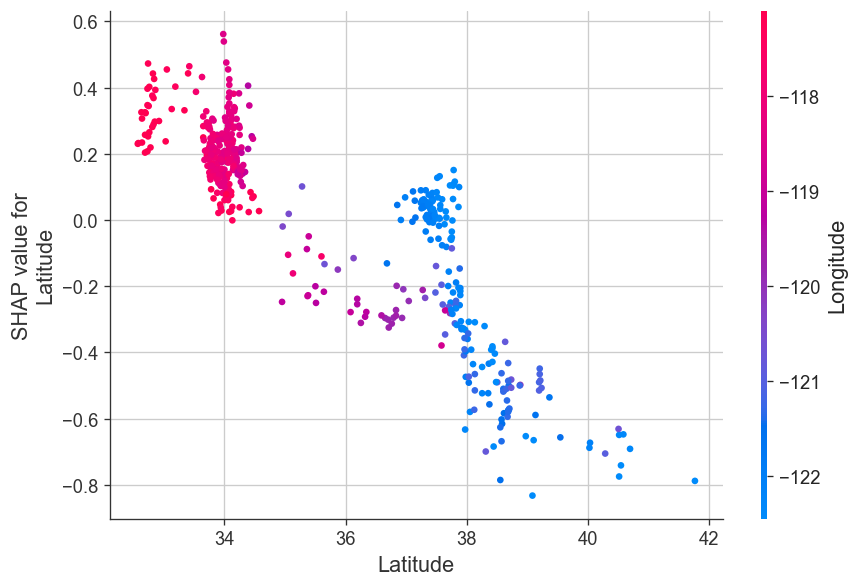

In [11]:
shap.dependence_plot('Latitude', shap_values, X_sample, interaction_index='Longitude', show=False)
plt.tight_layout()
plt.show()

### 3.5. Force Plot — интерактивное объяснение

Визуализация «сил», которые толкают предсказание вверх или вниз.

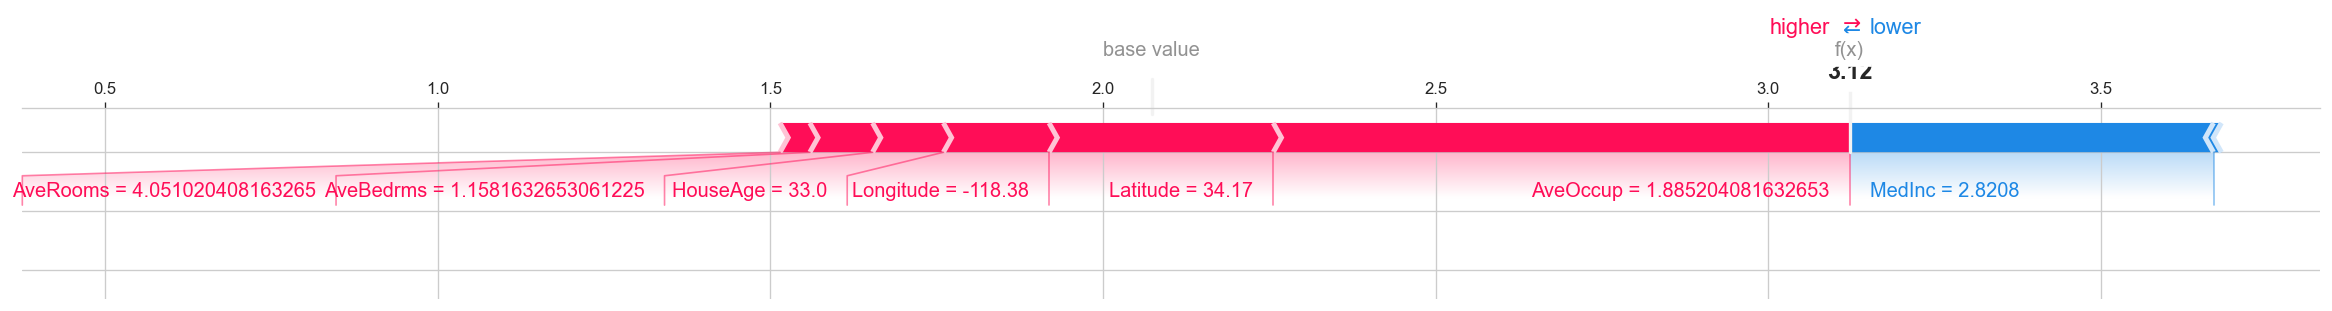

In [12]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_sample.iloc[0],
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.show()

### 3.6. Decision Plot — кумулятивный вклад признаков

Показывает траекторию предсказания: как оно накапливается при последовательном учёте признаков.

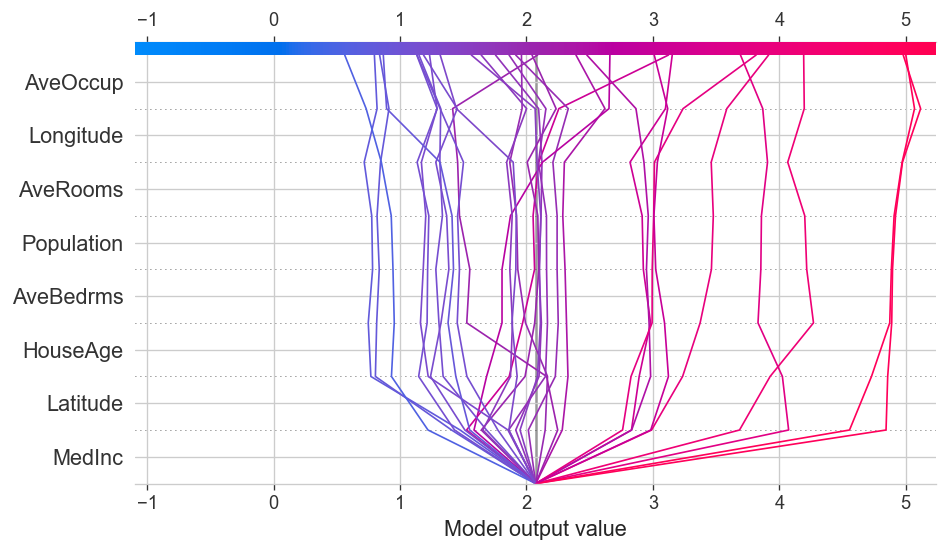

In [13]:
shap.decision_plot(
    explainer.expected_value,
    shap_values[:30],
    X_sample.iloc[:30],
    feature_order='hclust',
    show=False
)
plt.tight_layout()
plt.show()

## 4. Сравнение моделей через SHAP

Обучим XGBoost и сравним важность признаков с Random Forest.

In [14]:
xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
print(f'XGBoost RMSE: {xgb_rmse:.4f}')

XGBoost RMSE: 0.4639


100%|██████████| 500/500 [00:09<00:00, 51.00it/s]


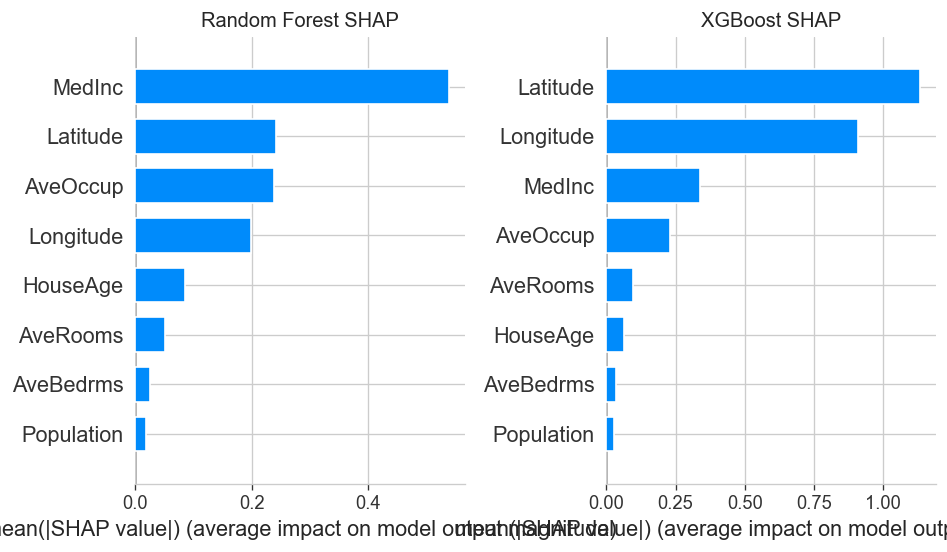

In [19]:
X_bg_xgb = shap.kmeans(X_train, 50)

explainer_xgb = shap.KernelExplainer(lambda x: xgb_model.predict(x), X_bg_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_sample, nsamples=200)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plt.subplot(1, 2, 1)
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('Random Forest SHAP')

plt.subplot(1, 2, 2)
shap.summary_plot(shap_values_xgb, X_sample, plot_type='bar', show=False)
plt.title('XGBoost SHAP')

plt.tight_layout()
plt.show()

**Вывод:** хотя обе модели показывают схожую картину важности признаков, возможны различия в порядке и величине — это отражает разную внутреннюю логику моделей.

## 5. Задача классификации: Breast Cancer Wisconsin

Предсказываем, является ли опухоль злокачественной (1) или доброкачественной (0).

In [20]:
cancer = load_breast_cancer(as_frame=True)
X_c = cancer.data
y_c = cancer.target

print(f'Размер данных: {X_c.shape}')
print(f'Признаки: {len(X_c.columns)}')
print(f'Распределение классов: 0 — {sum(y_c == 0)}, 1 — {sum(y_c == 1)}')
X_c.head()

Размер данных: (569, 30)
Признаки: 30
Распределение классов: 0 — 212, 1 — 357


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [21]:
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
clf.fit(Xc_train, yc_train)

yc_pred = clf.predict(Xc_test)
print(f'Accuracy: {accuracy_score(yc_test, yc_pred):.4f}')
print(classification_report(yc_test, yc_pred, target_names=cancer.target_names))

Accuracy: 0.9649
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [22]:
explainer_clf = shap.TreeExplainer(clf)

Xc_sample = Xc_test.sample(n=100, random_state=42)
shap_values_clf = explainer_clf.shap_values(Xc_sample)

print(f'Тип результата: {type(shap_values_clf)}')
print(f'Форма SHAP: {shap_values_clf.shape}')

if shap_values_clf.ndim == 3:
    current_shap = shap_values_clf[:, :, 1]
    print(f'Выбран класс 1 (злокачественная), форма: {current_shap.shape}')
elif isinstance(shap_values_clf, list):
    current_shap = shap_values_clf[1]
    print(f'Выбран класс 1, форма: {current_shap.shape}')
else:
    current_shap = shap_values_clf

Тип результата: <class 'numpy.ndarray'>
Форма SHAP: (100, 30, 2)
Выбран класс 1 (злокачественная), форма: (100, 30)


### 5.1. Summary Plot для классификации

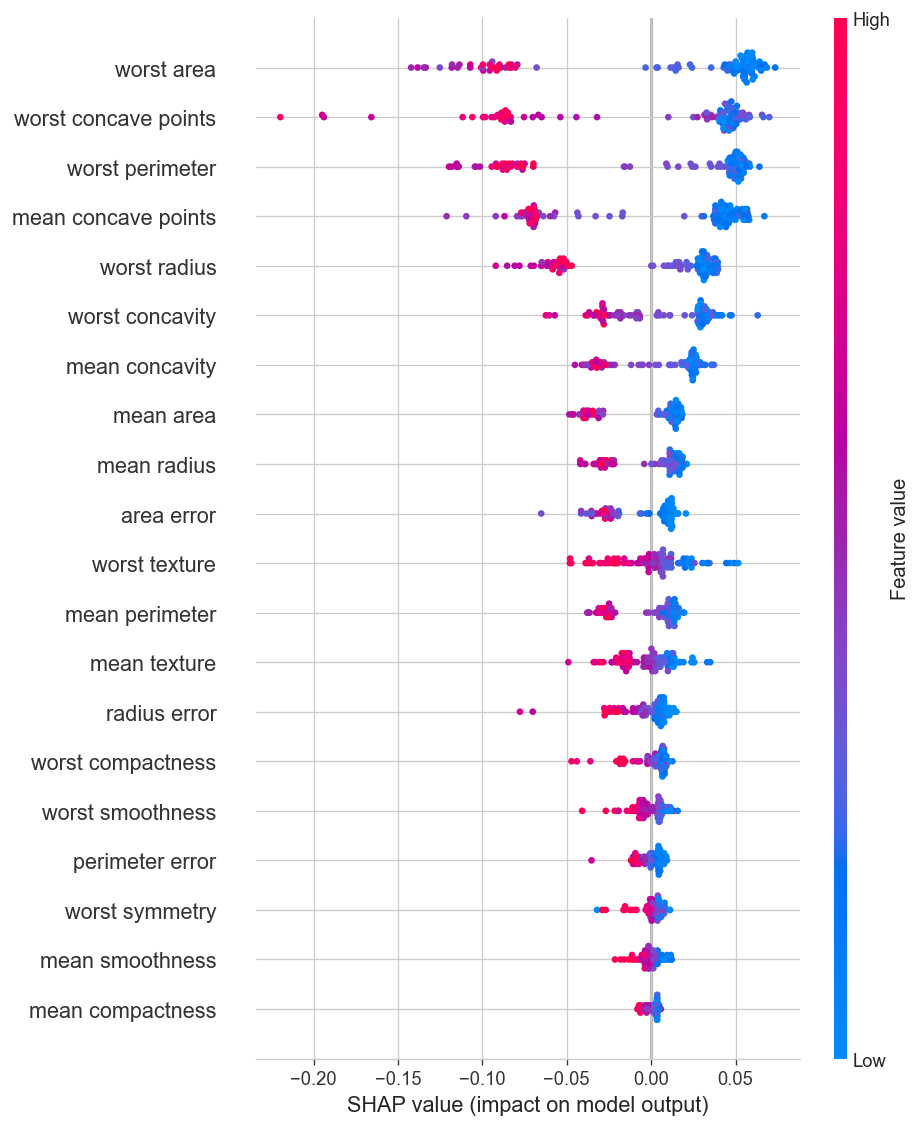

In [23]:
shap.summary_plot(current_shap, Xc_sample, show=False)
plt.tight_layout()
plt.show()

### 5.2. Waterfall Plot — объяснение одного диагноза

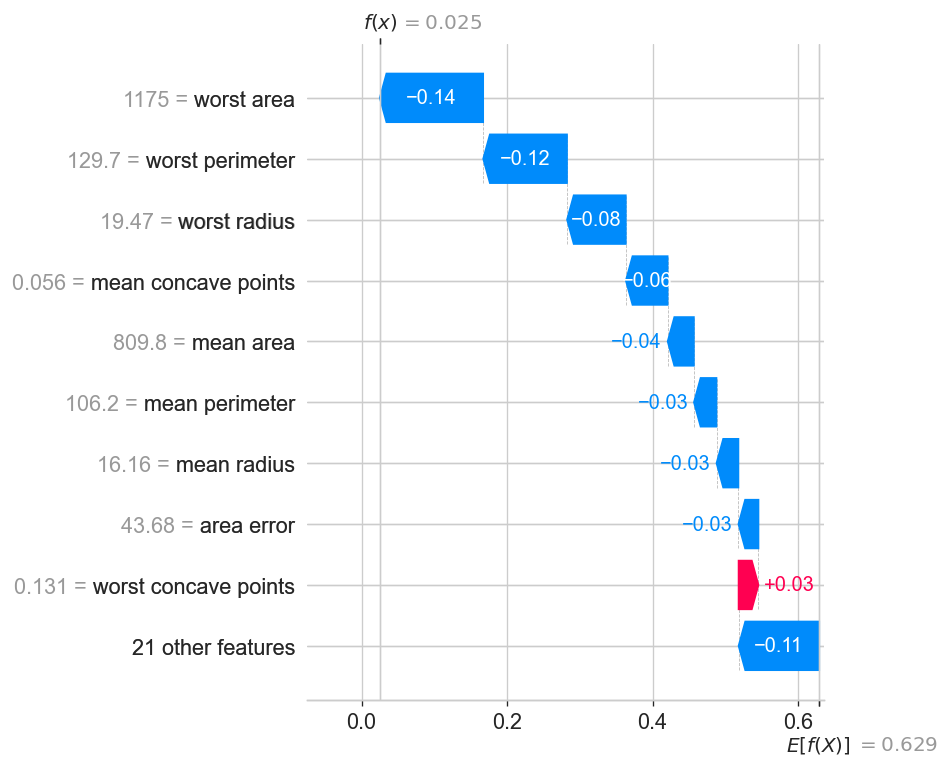

Истинный класс: malignant
Предсказанная вероятность: класс 0 = 0.9750, класс 1 = 0.0250


In [24]:
exp_val = explainer_clf.expected_value
if isinstance(exp_val, (np.ndarray, list)) and not np.isscalar(exp_val):
    base_val = exp_val[1] if len(exp_val) > 1 else exp_val[0]
else:
    base_val = exp_val

shap.waterfall_plot(
    shap.Explanation(
        values=current_shap[0],
        base_values=base_val,
        data=Xc_sample.iloc[0].values,
        feature_names=Xc_sample.columns.tolist()
    ),
    show=False
)
plt.tight_layout()
plt.show()

true_label = yc_test.loc[Xc_sample.index[0]]
pred_proba = clf.predict_proba(Xc_sample.iloc[[0]])[0]
print(f'Истинный класс: {cancer.target_names[true_label]}')
print(f'Предсказанная вероятность: класс 0 = {pred_proba[0]:.4f}, класс 1 = {pred_proba[1]:.4f}')

### 5.3. Dependence Plot для классификации

Признак: mean radius


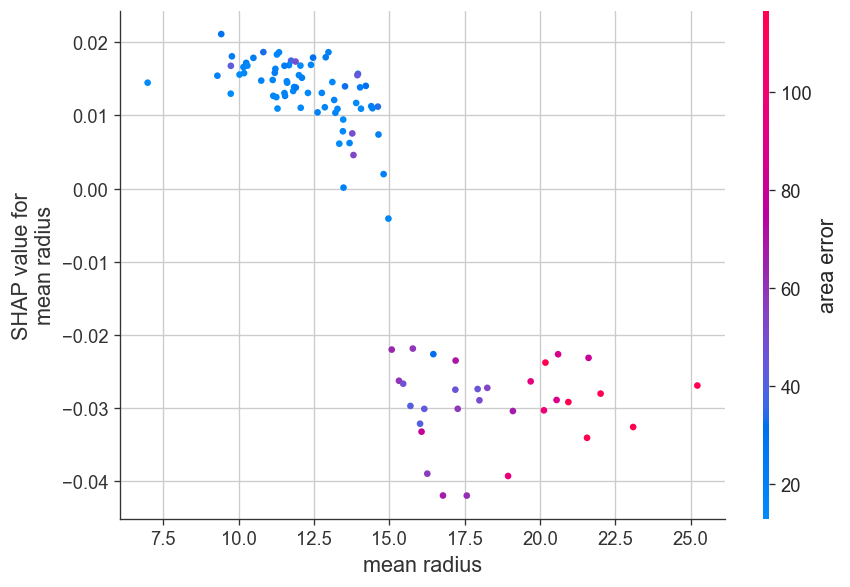

In [25]:
top_feature = X_c.columns[0]
print(f'Признак: {top_feature}')
shap.dependence_plot(top_feature, current_shap, Xc_sample, show=False)
plt.tight_layout()
plt.show()

## 6. KernelExplainer — SHAP для любой модели

KernelExplainer работает с ЛЮБОЙ моделью (не только древовидной), но медленнее. Для демонстрации используем подвыборку.

In [26]:
X_bg = shap.kmeans(X_train, 50)

kernel_explainer = shap.KernelExplainer(rf.predict, X_bg)

X_small = X_test.sample(n=20, random_state=42)
kernel_shap = kernel_explainer.shap_values(X_small, nsamples=100)

print(f'Форма Kernel SHAP: {kernel_shap.shape}')

100%|██████████| 20/20 [00:03<00:00,  5.15it/s]

Форма Kernel SHAP: (20, 8)


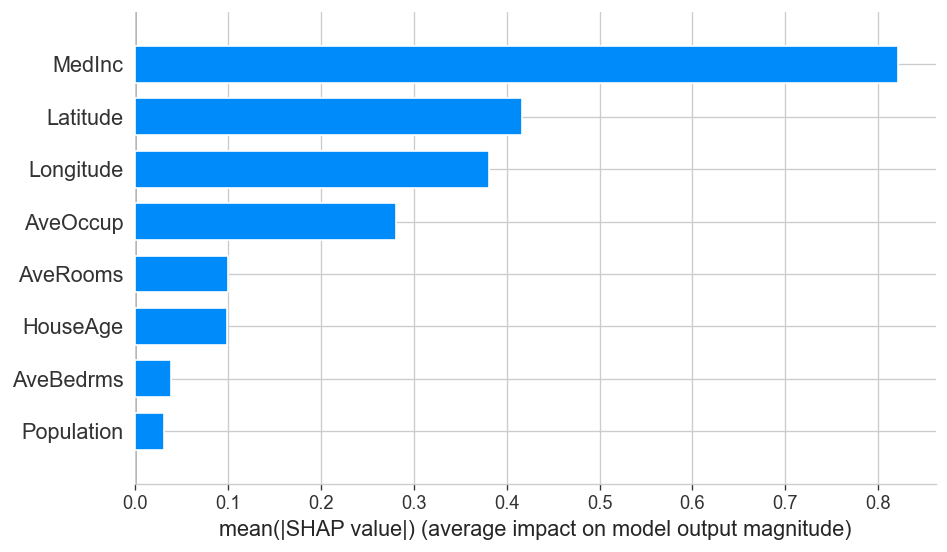

In [27]:
shap.summary_plot(kernel_shap, X_small, plot_type='bar', show=False)
plt.tight_layout()
plt.show()

## 7. Feature Interaction (взаимодействия признаков)

SHAP умеет разделять основной эффект признака и эффект взаимодействия с другими признаками.

In [28]:
shap_interaction = explainer.shap_interaction_values(X_sample)

print(f'Форма матрицы взаимодействий: {shap_interaction.shape}')
print(f'Интерпретация: shap_interaction[i, j] — эффект взаимодействия признаков i и j')

Форма матрицы взаимодействий: (500, 8, 8)
Интерпретация: shap_interaction[i, j] — эффект взаимодействия признаков i и j


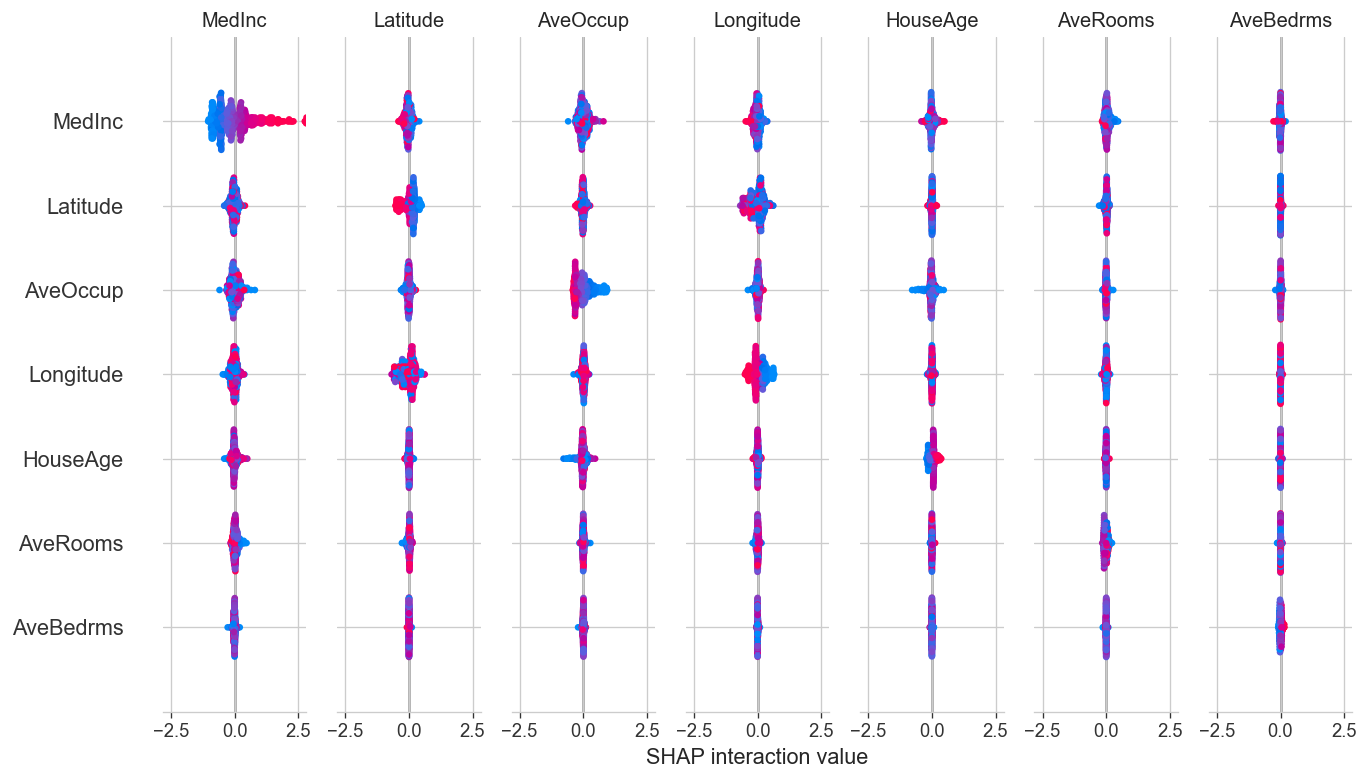

In [29]:
shap.summary_plot(shap_interaction, X_sample, show=False)
plt.tight_layout()
plt.show()

## 8. Итоги и ключевые выводы

**Что мы узнали:**

1. **SHAP даёт объяснимость на трёх уровнях:**
   - Глобальном (важность признаков для всей модели)
   - Локальном (объяснение конкретного предсказания)
   - Популяционном (паттерны в группах объектов)

2. **Основные графики SHAP:**
   - `summary_plot` — главный инструмент: важность + направление влияния
   - `bar plot` — быстрая оценка важности
   - `waterfall plot` — детальное объяснение одного объекта
   - `dependence plot` — нелинейные зависимости и взаимодействия
   - `force plot` — компактная визуализация «сил»
   - `decision plot` — траектория накопления предсказания

3. **TreeExplainer vs KernelExplainer:**
   - TreeExplainer — быстрый и точный для деревьев (Random Forest, XGBoost, LightGBM, CatBoost)
   - KernelExplainer — универсальный, но медленный

4. **Где SHAP особенно полезен:**
   - Медицина: объяснение диагнозов
   - Финансы: обоснование кредитных решений
   - Промышленность: поиск причин отказов
   - Отладка модели: какие признаки реально важны, а какие — шум